In [249]:
import numpy as np
import matplotlib.pyplot as plt
from pymdp.agent import Agent
from pymdp import utils
from copy import deepcopy
from pymdp.control import construct_policies  
import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
import jax
from pymdp.jax.agent import Agent # Path only exists on master branch, not in pip 0.0.7.1 or the v1.0.0 alpha branch

In [250]:
print(jax.devices())

[CpuDevice(id=0)]


In [251]:
grid_size = 4
win_length = 3  # e.g. 3 for classic tic tac toe
n_cells = grid_size * grid_size

# Empty Count options (0 to n_cells inclusive,so 17 vals for 16 cells)
empty_count_states = list(range(0, n_cells + 1))

CELL_EMPTY = 0
CELL_O = 1
CELL_X = 2
n_cell_states = 3
cell_labels = ["Empty", "O", "X"]

PLAYER_O = 0
PLAYER_X = 1
n_turn_states = 2  # O's turn, X's turn

ACTION_STAY = 0
ACTION_MARK = 1
n_empty_count_states = len(empty_count_states)

n_states = [n_cell_states] * n_cells + [n_turn_states] + [n_empty_count_states]

print(f"Number of states\n{n_cell_states} cell states * {n_cells} cells, 2 turn states, {n_empty_count_states} empty states:\n{n_states}")

Number of states
3 cell states * 16 cells, 2 turn states, 17 empty states:
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 17]


In [252]:
chunk_obs_labels = ['Empty', 'Unwinnable'] + [f'OIn{i}' for i in range(0, win_length)] + [f'XIn{i}' for i in range(0, win_length)]

def get_chunks(grid_size, win_length):
    """Return a list of lists, each sublist is indices of a winning line."""
    chunks = []
    # Rows
    for r in range(grid_size):
        for c in range(grid_size - win_length + 1):
            chunks.append([r * grid_size + c + i for i in range(win_length)])
    # Columns
    for c in range(grid_size):
        for r in range(grid_size - win_length + 1):
            chunks.append([(r + i) * grid_size + c for i in range(win_length)])
    # Diagonals
    for r in range(grid_size - win_length + 1):
        for c in range(grid_size - win_length + 1):
            # Down-right
            chunks.append([(r + i) * grid_size + (c + i) for i in range(win_length)])
            # Down-left
            chunks.append([(r + i) * grid_size + (c + win_length - 1 - i) for i in range(win_length)])
    return chunks

chunks = get_chunks(grid_size, win_length)
n_chunks = len(chunks)

cell_obs = [ 3 for _ in range(n_cells) ]
chunk_obs = [ len(chunk_obs_labels) for _ in range(n_chunks) ]
n_obs = [*cell_obs, 2, len(empty_count_states), *chunk_obs]

print("Chunk labels:", chunk_obs_labels)
print(f"Number of Chunks: {n_chunks}")
print(f"Chunk cell indices: {chunks}")
print(f"Observation Dimensionalities: {n_obs}")

Chunk labels: ['Empty', 'Unwinnable', 'OIn0', 'OIn1', 'OIn2', 'XIn0', 'XIn1', 'XIn2']
Number of Chunks: 24
Chunk cell indices: [[0, 1, 2], [1, 2, 3], [4, 5, 6], [5, 6, 7], [8, 9, 10], [9, 10, 11], [12, 13, 14], [13, 14, 15], [0, 4, 8], [4, 8, 12], [1, 5, 9], [5, 9, 13], [2, 6, 10], [6, 10, 14], [3, 7, 11], [7, 11, 15], [0, 5, 10], [2, 5, 8], [1, 6, 11], [3, 6, 9], [4, 9, 14], [6, 9, 12], [5, 10, 15], [7, 10, 13]]
Observation Dimensionalities: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 17, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


In [253]:
A_factor_list = []

for i in range(n_cells):
    A_factor_list.append([i])  # cell obs depend on cell state

A_factor_list.append([n_cells])  # turn obs depends on turn state
A_factor_list.append([n_cells+1])  # empty count obs depends on empty count state

for i, chunk in enumerate(chunks): # chunks depend on the cells they observe
    A_factor_list.append(chunk)

print(f"A dependencies: {A_factor_list}")

A dependencies: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [0, 1, 2], [1, 2, 3], [4, 5, 6], [5, 6, 7], [8, 9, 10], [9, 10, 11], [12, 13, 14], [13, 14, 15], [0, 4, 8], [4, 8, 12], [1, 5, 9], [5, 9, 13], [2, 6, 10], [6, 10, 14], [3, 7, 11], [7, 11, 15], [0, 5, 10], [2, 5, 8], [1, 6, 11], [3, 6, 9], [4, 9, 14], [6, 9, 12], [5, 10, 15], [7, 10, 13]]


In [254]:
A = utils.obj_array(len(n_obs))
for i in range(len(n_obs)):
    A[i] = np.zeros((n_obs[i],) + tuple([n_states[j] for j in A_factor_list[i]]))

# For each modality, its observation count followed by the counts of every hidden state it depends on.
for i in range(len(n_obs)):
    print(f"A[{i}] shape: {A[i].shape}")

A[0] shape: (3, 3)
A[1] shape: (3, 3)
A[2] shape: (3, 3)
A[3] shape: (3, 3)
A[4] shape: (3, 3)
A[5] shape: (3, 3)
A[6] shape: (3, 3)
A[7] shape: (3, 3)
A[8] shape: (3, 3)
A[9] shape: (3, 3)
A[10] shape: (3, 3)
A[11] shape: (3, 3)
A[12] shape: (3, 3)
A[13] shape: (3, 3)
A[14] shape: (3, 3)
A[15] shape: (3, 3)
A[16] shape: (2, 2)
A[17] shape: (17, 17)
A[18] shape: (8, 3, 3, 3)
A[19] shape: (8, 3, 3, 3)
A[20] shape: (8, 3, 3, 3)
A[21] shape: (8, 3, 3, 3)
A[22] shape: (8, 3, 3, 3)
A[23] shape: (8, 3, 3, 3)
A[24] shape: (8, 3, 3, 3)
A[25] shape: (8, 3, 3, 3)
A[26] shape: (8, 3, 3, 3)
A[27] shape: (8, 3, 3, 3)
A[28] shape: (8, 3, 3, 3)
A[29] shape: (8, 3, 3, 3)
A[30] shape: (8, 3, 3, 3)
A[31] shape: (8, 3, 3, 3)
A[32] shape: (8, 3, 3, 3)
A[33] shape: (8, 3, 3, 3)
A[34] shape: (8, 3, 3, 3)
A[35] shape: (8, 3, 3, 3)
A[36] shape: (8, 3, 3, 3)
A[37] shape: (8, 3, 3, 3)
A[38] shape: (8, 3, 3, 3)
A[39] shape: (8, 3, 3, 3)
A[40] shape: (8, 3, 3, 3)
A[41] shape: (8, 3, 3, 3)


In [255]:
def get_chunk_obs(chunk_cell_states):
    n_empty = sum([s == CELL_EMPTY for s in chunk_cell_states])
    n_O = sum([s == CELL_O for s in chunk_cell_states])
    n_X = sum([s == CELL_X for s in chunk_cell_states])
    if n_empty == len(chunk_cell_states):
        return chunk_obs_labels.index('Empty')
    if n_O > 0 and n_X > 0:
        return chunk_obs_labels.index('Unwinnable')
    if n_X == 0:
        return chunk_obs_labels.index('OIn1') + n_empty - 1
    if n_O == 0:
        return chunk_obs_labels.index('XIn1') + n_empty - 1
    raise ValueError("Invalid chunk state")

In [256]:
# Cell observations - identity
for i in range(n_cells):
    for state in range(3):
        A[i][state, state] = 1.

# Turn observation - identity
turn_idx = n_cells
for state in range(2):
    A[turn_idx][state, state] = 1.0

# Empty count observation - identity
empty_count_idx = n_cells + 1
for state in range(n_empty_count_states):
    A[empty_count_idx][state, state] = 1.0

# Chunk observations.
chunk_start_idx = n_cells + 2
for i, chunk in enumerate(chunks):
    for cell_states in np.ndindex((3,) * win_length):
        obs = get_chunk_obs(cell_states)
        print(f"Chunk {i} {list(map(lambda c: cell_labels[c], cell_states))} is {chunk_obs_labels[obs]}")
        A[chunk_start_idx + i][obs, *cell_states] = 1.0

Chunk 0 ['Empty', 'Empty', 'Empty'] is Empty
Chunk 0 ['Empty', 'Empty', 'O'] is OIn2
Chunk 0 ['Empty', 'Empty', 'X'] is XIn2
Chunk 0 ['Empty', 'O', 'Empty'] is OIn2
Chunk 0 ['Empty', 'O', 'O'] is OIn1
Chunk 0 ['Empty', 'O', 'X'] is Unwinnable
Chunk 0 ['Empty', 'X', 'Empty'] is XIn2
Chunk 0 ['Empty', 'X', 'O'] is Unwinnable
Chunk 0 ['Empty', 'X', 'X'] is XIn1
Chunk 0 ['O', 'Empty', 'Empty'] is OIn2
Chunk 0 ['O', 'Empty', 'O'] is OIn1
Chunk 0 ['O', 'Empty', 'X'] is Unwinnable
Chunk 0 ['O', 'O', 'Empty'] is OIn1
Chunk 0 ['O', 'O', 'O'] is OIn0
Chunk 0 ['O', 'O', 'X'] is Unwinnable
Chunk 0 ['O', 'X', 'Empty'] is Unwinnable
Chunk 0 ['O', 'X', 'O'] is Unwinnable
Chunk 0 ['O', 'X', 'X'] is Unwinnable
Chunk 0 ['X', 'Empty', 'Empty'] is XIn2
Chunk 0 ['X', 'Empty', 'O'] is Unwinnable
Chunk 0 ['X', 'Empty', 'X'] is XIn1
Chunk 0 ['X', 'O', 'Empty'] is Unwinnable
Chunk 0 ['X', 'O', 'O'] is Unwinnable
Chunk 0 ['X', 'O', 'X'] is Unwinnable
Chunk 0 ['X', 'X', 'Empty'] is XIn1
Chunk 0 ['X', 'X', 'O'] i

In [257]:
all_normalized = True
for m in range(len(A)):
    # Sum over observation dimension (axis 0) should be 1 for all state configs
    sum_over_obs = A[m].sum(axis=0)
    is_norm_m = np.allclose(sum_over_obs, 1.0)
    if not is_norm_m:
        print(f"Warning: A[{m}] is NOT normalized!")
        all_normalized = False

print(f"All A sub-arrays are normalized: {all_normalized}")

All A sub-arrays are normalized: True


In [258]:
n_controls = [2] * n_cells + [1, 1] # 2 actions for each cell: Stay or Mark. Null action for turn and empty count.
control_fac_idx = list(range(n_cells))  # only cell states are controllable

B_factor_list = []
for i in range(n_cells):
    B_factor_list.append([turn_idx, empty_count_idx, i])  # cell transitions depend on cell state, turn, empty count
B_factor_list.append([turn_idx])  # turn transition depends on turn state
B_factor_list.append([empty_count_idx])  # empty count transition depends on empty count state

print(f"Actions: {n_controls}")
print(f"Controllable items: {control_fac_idx}")
print(f"B dependencies: {B_factor_list}")

Actions: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1]
Controllable items: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
B dependencies: [[16, 17, 0], [16, 17, 1], [16, 17, 2], [16, 17, 3], [16, 17, 4], [16, 17, 5], [16, 17, 6], [16, 17, 7], [16, 17, 8], [16, 17, 9], [16, 17, 10], [16, 17, 11], [16, 17, 12], [16, 17, 13], [16, 17, 14], [16, 17, 15], [16], [17]]


In [259]:
BO = utils.obj_array(len(n_states))
BX = utils.obj_array(len(n_states))
for i in range(n_cells):
    BO[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    BX[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    for prev in range(n_cell_states):
        for turn in range(n_turn_states):
            for emptyCount in range(n_empty_count_states):
                for act in range(2):  # Stay, Mark
                    if turn == PLAYER_O:

                        # Update O on O's turn
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            BO[i][CELL_O, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes O
                        else:
                            BO[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        
                        # Update X on O's turn
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by O or remaining empty
                                BX[i][CELL_O, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                BX[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by O
                                BX[i][CELL_O, turn, emptyCount, prev, act] = 1.0
                        else:
                            BX[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged
                    else:

                        # Update X on X's turn
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            BX[i][CELL_X, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes X
                        else:
                            BX[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        
                        # Update O on X's turn
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by X or remaining empty
                                BO[i][CELL_X, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                BO[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by X
                                BO[i][CELL_X, turn, emptyCount, prev, act] = 1.0
                        else:
                            BO[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged


# Turn transitions
BO[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
BX[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
for s in range(n_turn_states):
    for prev in range(n_turn_states):
        BO[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0
        BX[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0

# Empty count transitions
BO[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
BX[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
for s in range(n_empty_count_states):
    for prev in range(n_empty_count_states):
        BO[empty_count_idx][max(0, s-1), s, 0] = 1.0
        BX[empty_count_idx][max(0, s-1), s, 0] = 1.0

for i in range(len(BO)):
    print(f"BO[{i}] shape: {BO[i].shape}")

BO[0] shape: (3, 2, 17, 3, 2)
BO[1] shape: (3, 2, 17, 3, 2)
BO[2] shape: (3, 2, 17, 3, 2)
BO[3] shape: (3, 2, 17, 3, 2)
BO[4] shape: (3, 2, 17, 3, 2)
BO[5] shape: (3, 2, 17, 3, 2)
BO[6] shape: (3, 2, 17, 3, 2)
BO[7] shape: (3, 2, 17, 3, 2)
BO[8] shape: (3, 2, 17, 3, 2)
BO[9] shape: (3, 2, 17, 3, 2)
BO[10] shape: (3, 2, 17, 3, 2)
BO[11] shape: (3, 2, 17, 3, 2)
BO[12] shape: (3, 2, 17, 3, 2)
BO[13] shape: (3, 2, 17, 3, 2)
BO[14] shape: (3, 2, 17, 3, 2)
BO[15] shape: (3, 2, 17, 3, 2)
BO[16] shape: (2, 2, 1)
BO[17] shape: (17, 17, 1)


In [260]:
for f in range(len(BO)):
    B_f = BO[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BO[{f}] column at {idx} sums to {col_sum:.3f}") 

In [261]:
for f in range(len(BX)):
    B_f = BX[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BX[{f}] column at {idx} sums to {col_sum:.3f}")    

In [262]:
from pymdp.control import construct_policies  
import numpy as np  
  
gen_policy_len = 1
all_policies = construct_policies(n_states, n_controls, policy_len=gen_policy_len)  

# Keep policies where exactly one controllable factor changes per timestep
# Each policy is a list of lists with one entry.
policies = [  
    p for p in all_policies
    if all(np.count_nonzero(p[t, control_fac_idx]) == 1 for t in range(gen_policy_len))
]

# We can chain a few of these one hot actions together as the restricted state space is manageable (grid size 4*4 with policy_len=3 = 16^3 = 4096 policies)
# We want the agent to be able to imagine their action on the turn after the opponent has moved, so they can integrate the uncertainty about the board state.
policy_len = 3
expanded_policies = []
for p in policies:
    for p2 in policies:
        for p3 in policies:
            new_policy = np.vstack([p, p2, p3])
            expanded_policies.append(new_policy)

print(f"Generated {len(expanded_policies)} policies:")
for i, pol in enumerate(expanded_policies):
    print(f"Policy {i}: {pol}")

Generated 4096 policies:
Policy 0: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]]
Policy 1: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]]
Policy 2: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]]
Policy 3: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]
Policy 4: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]]
Policy 5: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]]
Policy 6: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]]
Policy 7: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [263]:
CO = utils.obj_array_zeros(n_obs)
CX = utils.obj_array_zeros(n_obs)

# Cell obs: neutral
for i in range(n_cells):
    CO[i] = np.zeros(n_cell_states)
    CX[i] = np.zeros(n_cell_states)

# Turn obs: neutral
CO[turn_idx] = np.zeros(n_turn_states)
CX[turn_idx] = np.zeros(n_turn_states)

# Empty count obs: neutral
CO[empty_count_idx] = np.zeros(n_empty_count_states)
CX[empty_count_idx] = np.zeros(n_empty_count_states)

scaler = 2
# Chunk obs: increasingly positive for win, increasingly negative for lose.
# Win beats lose if equal distance.
# Don't care about unwinnable or empty.
for i in range(n_chunks):
    c_vec_o = np.zeros(len(chunk_obs_labels))
    c_vec_x = np.zeros(len(chunk_obs_labels))
    for j, label in enumerate(chunk_obs_labels):
        if label.startswith('OIn'):
            o_distance = int(label[len('OIn'):])
            o_score = (win_length - o_distance) ** scaler  # Higher score for smaller distance to win
            c_vec_o[j] = o_score # O reward for O gaining
            c_vec_x[j] = -o_score * 0.9 # X penalty for O gaining
        elif label.startswith('XIn'):
            x_distance = int(label[len('XIn'):])
            x_score = (win_length - x_distance) ** scaler  # Higher score for smaller distance to win
            c_vec_x[j] = x_score # X reward for X gaining
            c_vec_o[j] = -x_score * 0.9 # O penalty for X gaining

    CO[chunk_start_idx+i] = c_vec_o
    CX[chunk_start_idx+i] = c_vec_x

for i in range(len(CO)):
    print(f"CO[{i}] shape: {CO[i].shape}")

print(f"Chunk obs CO[{chunk_start_idx}] values: {CO[chunk_start_idx]}")
print(f"Chunk obs CX[{chunk_start_idx}] values: {CX[chunk_start_idx]}")

CO[0] shape: (3,)
CO[1] shape: (3,)
CO[2] shape: (3,)
CO[3] shape: (3,)
CO[4] shape: (3,)
CO[5] shape: (3,)
CO[6] shape: (3,)
CO[7] shape: (3,)
CO[8] shape: (3,)
CO[9] shape: (3,)
CO[10] shape: (3,)
CO[11] shape: (3,)
CO[12] shape: (3,)
CO[13] shape: (3,)
CO[14] shape: (3,)
CO[15] shape: (3,)
CO[16] shape: (2,)
CO[17] shape: (17,)
CO[18] shape: (8,)
CO[19] shape: (8,)
CO[20] shape: (8,)
CO[21] shape: (8,)
CO[22] shape: (8,)
CO[23] shape: (8,)
CO[24] shape: (8,)
CO[25] shape: (8,)
CO[26] shape: (8,)
CO[27] shape: (8,)
CO[28] shape: (8,)
CO[29] shape: (8,)
CO[30] shape: (8,)
CO[31] shape: (8,)
CO[32] shape: (8,)
CO[33] shape: (8,)
CO[34] shape: (8,)
CO[35] shape: (8,)
CO[36] shape: (8,)
CO[37] shape: (8,)
CO[38] shape: (8,)
CO[39] shape: (8,)
CO[40] shape: (8,)
CO[41] shape: (8,)
Chunk obs CO[18] values: [ 0.   0.   9.   4.   1.  -8.1 -3.6 -0.9]
Chunk obs CX[18] values: [ 0.   0.  -8.1 -3.6 -0.9  9.   4.   1. ]


In [264]:
def getDForPlayer(startingPlayer, player):
    D = utils.obj_array(len(n_states))
    # Cell states
    for i in range(n_cells):
        d = np.zeros(n_cell_states)
        if startingPlayer == player:
            d[CELL_EMPTY] = 1.0 # All empty
        else:            
            d[CELL_EMPTY] = (n_cells - 1) / n_cells  # Most empty
            if player == PLAYER_O:
                d[CELL_X] = 1.0 / n_cells  # One will be marked by opponent
            else: 
                d[CELL_O] = 1.0 / n_cells
        D[i] = d

    # Turn state
    turn_d = np.zeros(n_turn_states)
    turn_d[startingPlayer] = 1.0
    D[n_cells] = turn_d

    # Empty count state
    empty_d = np.zeros(n_empty_count_states)
    empty_d[-1] = 1.0  # start with all cells empty (index n_cells - 1)
    D[n_cells+1] = empty_d
    return D

startingPlayer = PLAYER_O
DO = getDForPlayer(startingPlayer=startingPlayer, player=PLAYER_O)
DX = getDForPlayer(startingPlayer=startingPlayer, player=PLAYER_X)

print("D matrices initialized for factorized state space:")
for i in range(len(DO)):
    print(f"DO[{i}] shape: {DO[i].shape}")
    print(f"State prior {i}: {DO[i]}")
for i in range(len(DX)):
    print(f"DX[{i}] shape: {DX[i].shape}")
    print(f"State prior {i}: {DX[i]}")

D matrices initialized for factorized state space:
DO[0] shape: (3,)
State prior 0: [1. 0. 0.]
DO[1] shape: (3,)
State prior 1: [1. 0. 0.]
DO[2] shape: (3,)
State prior 2: [1. 0. 0.]
DO[3] shape: (3,)
State prior 3: [1. 0. 0.]
DO[4] shape: (3,)
State prior 4: [1. 0. 0.]
DO[5] shape: (3,)
State prior 5: [1. 0. 0.]
DO[6] shape: (3,)
State prior 6: [1. 0. 0.]
DO[7] shape: (3,)
State prior 7: [1. 0. 0.]
DO[8] shape: (3,)
State prior 8: [1. 0. 0.]
DO[9] shape: (3,)
State prior 9: [1. 0. 0.]
DO[10] shape: (3,)
State prior 10: [1. 0. 0.]
DO[11] shape: (3,)
State prior 11: [1. 0. 0.]
DO[12] shape: (3,)
State prior 12: [1. 0. 0.]
DO[13] shape: (3,)
State prior 13: [1. 0. 0.]
DO[14] shape: (3,)
State prior 14: [1. 0. 0.]
DO[15] shape: (3,)
State prior 15: [1. 0. 0.]
DO[16] shape: (2,)
State prior 16: [1. 0.]
DO[17] shape: (17,)
State prior 17: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
DX[0] shape: (3,)
State prior 0: [0.9375 0.0625 0.    ]
DX[1] shape: (3,)
State prior 1: [0.9375 0.06

In [265]:
for f in range(len(DX)):
    D_f = DX[f]
    total = D_f.sum()
    if not np.isclose(total, 1.0):
        print(f"Warning: D[{f}] sums to {total:.3f}")

In [266]:
# --- Environment Implementation ---
class TicTacToeEnv:
    def __init__(self, grid_size, win_length):
        self.grid_size = grid_size
        self.n_cells = grid_size * grid_size
        self.win_length = win_length
        self.chunks = get_chunks(grid_size, win_length)
        self.reset()

    def reset(self):
        self.cells = [0] * self.n_cells  # all empty
        self.turn = PLAYER_O
        self.empty_count = self.n_cells
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        obs_cells = deepcopy(self.cells)
        obs_chunks = []
        for chunk in self.chunks:
            chunk_states = [self.cells[i] for i in chunk]
            obs_chunks.append(get_chunk_obs(chunk_states))
        return tuple(obs_cells) + (self.turn,) + (self.empty_count,) + tuple(obs_chunks)

    def step(self, action, agent):
        # action: index of cell to mark
        if self.done:
            return self._get_obs(), 0, True
        
        if self.turn == agent: # Don't allow the agent to play for the opponent
            if self.cells[action] == CELL_EMPTY:
                self.cells[action] = CELL_O if agent == PLAYER_O else CELL_X
                self.empty_count -= 1
            # Check for win/draw
            winner = self._check_winner()
            if winner is not None or self.empty_count == 0:
                self.done = True
                return self._get_obs(), winner, True
            # Switch turn
            self.turn = 1 - self.turn
           
        return self._get_obs(), 0, False

    def _check_winner(self):
        for chunk in self.chunks:
            vals = [self.cells[i] for i in chunk]
            if all(v == CELL_O for v in vals):
                return 1  # O wins
            if all(v == CELL_X for v in vals):
                return -1  # X wins
        return None


In [267]:
A_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(A))
BO_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(BO))
BX_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(BX))
CO_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(CO))
CX_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(CX))
DO_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(DO))
DX_jax = jtu.tree_map(lambda x: jnp.array(x)[None], list(DX))
policies_jax = jnp.array(expanded_policies)

agent_O = Agent(onehot_obs=False, A=A_jax, B=BO_jax, C=CO_jax, D=DO_jax, E=None, pA=None, pB=None, sampling_mode="full", policies=policies_jax, policy_len=policy_len, A_dependencies=A_factor_list, B_dependencies=B_factor_list, control_fac_idx=control_fac_idx)
agent_X = Agent(onehot_obs=False, A=A_jax, B=BX_jax, C=CX_jax, D=DX_jax, E=None, pA=None, pB=None, sampling_mode="full", policies=policies_jax, policy_len=policy_len, A_dependencies=A_factor_list, B_dependencies=B_factor_list, control_fac_idx=control_fac_idx)

In [268]:
def count_chunk_states(env):
    counts = {label: 0 for label in chunk_obs_labels}
    for chunk in chunks:
        chunk_cell_states = [env.cells[i] for i in chunk]
        obs_idx = get_chunk_obs(chunk_cell_states)
        label = chunk_obs_labels[obs_idx]
        counts[label] += 1
    return counts

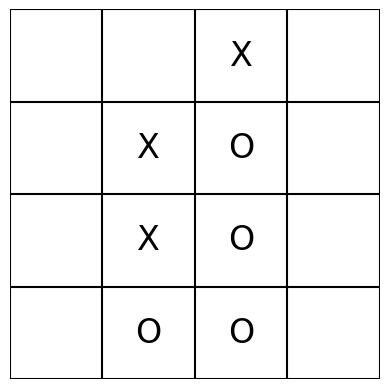

O wins!


In [269]:
from IPython.display import clear_output
import time

def plot_board(cells, grid_size):
    fig, ax = plt.subplots()
    for i in range(grid_size + 1):
        ax.axhline(i - 0.5, color='black')
        ax.axvline(i - 0.5, color='black')
    for i, cell in enumerate(cells):
        r, c = divmod(i, grid_size)
        if cell == 0:
            label = ''
        elif cell == 1:
            label = 'O'
        else:
            label = 'X'
        ax.text(c, r, label, fontsize=24, ha='center', va='center')
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()

env = TicTacToeEnv(grid_size, win_length)
obs = env.reset()

debug = False
# debug = True

if not debug:
    plot_board(env.cells, grid_size)

# Starting priors
empirical_prior_O = agent_O.D
empirical_prior_X = agent_X.D

for step in range(n_cells):

    if debug:
        print(f"Chunk states: {count_chunk_states(env)}")
        print(f"Step {step}, Turn: {'O' if env.turn == PLAYER_O else 'X'}")
        print(f"Observation: {obs}")
        print("Inferring states...")
        
    # Properly batch each modality for JAX agent, matching the expected arity and onehot_obs=False
    batch_obs = []
    # Cells
    for i in range(n_cells):
        batch_obs.append(jnp.array([[obs[i]]], dtype=jnp.int32))
    # Turn
    batch_obs.append(jnp.array([[obs[n_cells]]], dtype=jnp.int32))
    # Empty count
    batch_obs.append(jnp.array([[obs[n_cells+1]]], dtype=jnp.int32))
    # Chunks
    for i in range(n_chunks):
        batch_obs.append(jnp.array([[obs[n_cells+2+i]]], dtype=jnp.int32))

    qs_O = agent_O.infer_states(batch_obs, empirical_prior_O)
    qs_X = agent_X.infer_states(batch_obs, empirical_prior_X)

    if debug:
        print("Inferring policies...")

    q_pi_O, G = agent_O.infer_policies(qs_O)
    q_pi_X, G = agent_X.infer_policies(qs_X)

    if debug:
        print("Sampling actions...")

    chosen_action_O = agent_O.sample_action(q_pi_O)
    ep_O, qs_O = agent_O.update_empirical_prior(chosen_action_O, qs_O)
    empirical_prior_O = ep_O

    chosen_action_X = agent_X.sample_action(q_pi_X)
    empirical_prior_X, qs_X = agent_X.update_empirical_prior(chosen_action_X, qs_X)

    # Should always choose a single action as we pass in a filtered policy list
    try:
        mark_action_id_O = np.where(chosen_action_O[0] == 1)[0][0]
        if debug:
            print("O's policy posterior:", q_pi_O)
            print("O's max policy strength:", np.max(q_pi_O))
            print("O's sampled action:", chosen_action_O)
            print(f"O's mark action index: {mark_action_id_O}")
    except IndexError:
        raise ValueError("Null action sampled for O")
    try:
        mark_action_id_X = np.where(chosen_action_X[0] == 1)[0][0]
        if debug:
            print("X's policy posterior:", q_pi_X)
            print("X's max policy strength:", np.max(q_pi_X))
            print("X's sampled action:", chosen_action_X)
            print(f"X's mark action index: {mark_action_id_X}")
    except IndexError:
        raise ValueError("Null action sampled for X")

    if env.turn == PLAYER_O:
        if debug:
            print("Executing O action...")
        obs, reward, done = env.step(mark_action_id_O, agent=PLAYER_O)
    else:  # X's turn
        if debug:
            print("Executing X action...")
        obs, reward, done = env.step(mark_action_id_X, agent=PLAYER_X)

    if not debug:
        clear_output(wait=True)
        plot_board(env.cells, grid_size)
    
    # if grid_size == 3 and win_length == 3 and policy_len == 1:
    #     time.sleep(1) # Add delay to make it easier to track progress in fast game
    if debug:
        print("\n\n")
    if done:
        if reward == 1:
            print('O wins!')
        elif reward == -1:
            print('X wins!')
        else:
            print('Draw!')
        break